In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None


Проверяем формат столбцов

In [5]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [8]:
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB
None


Сгруппируйте данные по дате, посчитайте количество продаж

In [12]:
grouped_df = df.groupby('Дата')['Количество'].sum()
print(daily_sales.head())

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64


Вывести несколько первых строк сгруппированных данных

Нарисуйте график продаж у `grouped_df`

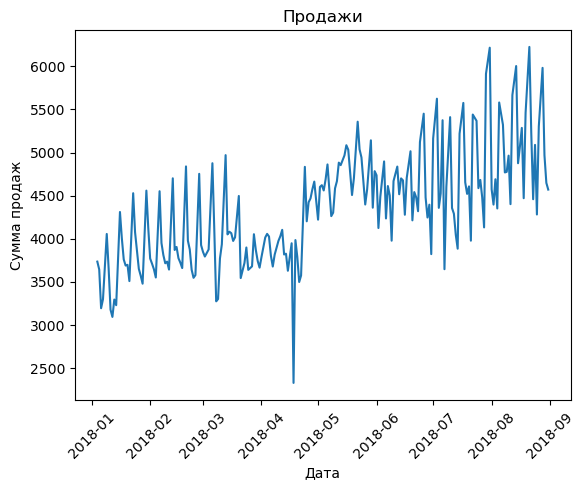

In [16]:
plt.plot(grouped_df)
plt.title('Продажи')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.xticks(rotation = 45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
# на графике продажи в разрезе месяцев за период с января по сентябрь 2018
# январь - март: диапазон в коридоре 3000-5000, в апреле резкий спад, в мае восстановление с последущим ежемесячным ростом
# Апрель выпадает из общего тренда и требует анализа причин спада

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [21]:
max_outlier = df.loc[df['Количество'].idxmax()]
max_outlier_value = df['Количество'].max()
print(f'Строка, у которой максимальный выброс по количеству продаж {max_outlier} со значением {max_outlier_value}')

Строка, у которой максимальный выброс по количеству продаж Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object со значением 200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [22]:
df['Месяц'] = df['Дата'].dt.month
df['День Недели'] = df['Дата'].dt.day_name()

In [23]:
print(df.head())

        Дата  Склад Контрагент Номенклатура  Количество  Месяц День Недели
0 2018-01-04      1  address_0    product_0           4      1    Thursday
1 2018-01-04      1  address_0    product_1           4      1    Thursday
2 2018-01-04      1  address_0    product_2           5      1    Thursday
3 2018-01-04      1  address_0    product_3          10      1    Thursday
4 2018-01-04      1  address_0    product_4           2      1    Thursday


In [29]:
groupby_df = df[
    (df['Склад'] ==3)&
    (df['Месяц'].isin([6,7,8]))&
    (df['День Недели'] == 'Wednesday')]
product_filter = groupby_df.groupby('Номенклатура')['Количество'].sum()
print(f'топовый товар по продажам по средам за июнь, июль, август у 3 склада {product_filter.idxmax()}')

топовый товар по продажам по средам за июнь, июль, август у 3 склада product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [39]:
import gzip
df_weather = pd.read_csv('35188.01.01.2018.31.12.2018.1.0.0.ru.utf8.00000000.csv.gz', compression = 'gzip', sep ='\t')

In [40]:
print(df_weather.head(100))

   # Метеостанция Астана, Казахстан, WMO_ID=35188, выборка с 01.01.2018 по 31.12.2018, все дни
0                                  # Кодировка: UTF-8                                         
1   # Информация предоставлена сайтом "Расписание ...                                         
2   # Пожалуйста, при использовании данных, любезн...                                         
3   # Обозначения метеопараметров см. по адресу ht...                                         
4                                                   #                                         
..                                                ...                                         
95  20.12.2018 20:00;"-19.8";"753.4";"789.5";"1.1"...                                         
96  20.12.2018 17:00;"-18.9";"752.3";"788.2";"1.9"...                                         
97  20.12.2018 14:00;"-15.6";"750.4";"785.8";"1.1"...                                         
98  20.12.2018 11:00;"-13.7";"749.3";"784.4";"2.7"

In [72]:
df_weather = pd.read_csv('35188.01.01.2018.31.12.2018.1.0.0.ru.utf8.00000000.csv.gz', 
                         compression='gzip', 
                         sep='\t', # табуляция как разделитель
                         encoding='utf-8',
                         skiprows=6,
                         header=None,
                         names=['data']) # одна колонка

# Разделяем по точке с запятой
df_split = df_weather['data'].str.split(';', expand=True)

# Берем нужные колонки
df_weather = df_split.iloc[:, :2] # только дата и температура
df_weather.columns = ['Дата_время', 'Температура']

# Очищаем
df_weather['Температура'] = df_weather['Температура'].str.replace('"', '')
df_weather['Температура'] = pd.to_numeric(df_weather['Температура'], errors='coerce')
df_weather['Дата_время'] = pd.to_datetime(df_weather['Дата_время'], format='%d.%m.%Y %H:%M', errors='coerce')

# Удаляем пропуски
df_weather = df_weather.dropna()

C:\Users\Админ\AppData\Local\Temp\ipykernel_1172\1619601627.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_weather['Температура'] = df_weather['Температура'].str.replace('"', '')
C:\Users\Админ\AppData\Local\Temp\ipykernel_1172\1619601627.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_weather['Температура'] = pd.to_numeric(df_weather['Температура'], errors='coerce')
C:\Users\Админ\AppData\Local\Temp\ipykernel_1172\1619601627.py:19: SettingWithCopyWarning: 
A value is trying to be set on a 

In [74]:
df_weather['Дата'] = df_weather['Дата_время'].dt.date
daily_weather = df_weather.groupby('Дата')['Температура'].mean().reset_index()
daily_weather.columns = ['Дата', 'Средняя температура']
daily_weather['Дата'] = pd.to_datetime(daily_weather['Дата'])
print(daily_weather.head())

        Дата  Средняя температура
0 2018-01-01              -9.4625
1 2018-01-02              -9.5125
2 2018-01-03             -11.4625
3 2018-01-04             -14.0750
4 2018-01-05             -16.8625


In [47]:
print(daily_weather.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Дата                 365 non-null    datetime64[ns]
 1   Средняя температура  365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB
None


In [48]:
combined_data = pd.merge(groupby_df, daily_weather, on = 'Дата', how = 'inner')

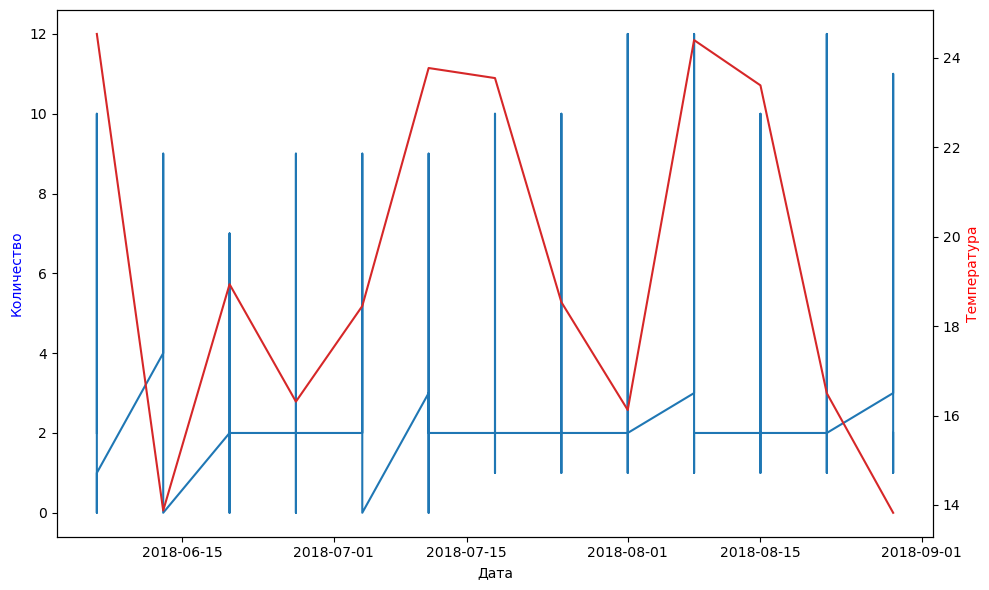

In [71]:
x = combined_data['Дата']
y_sales = combined_data['Количество']
y_temp = combined_data['Средняя температура']

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(x, y_sales, color='tab:blue')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество', color='blue')

ax2 = ax1.twinx()
ax2.plot(x, y_temp, color='tab:red')
ax2.set_ylabel('Температура', color='red')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

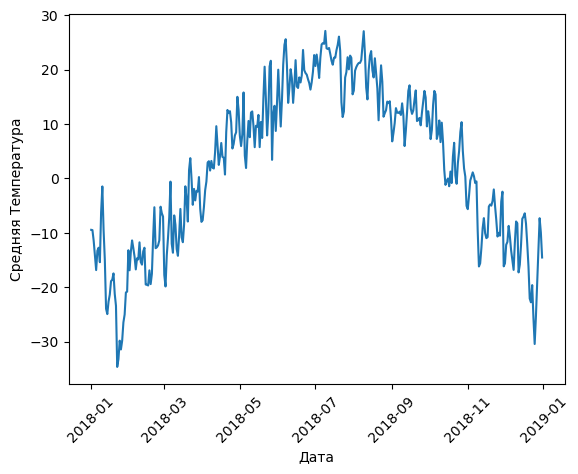

In [61]:
plt.plot(daily_weather['Дата'], daily_weather['Средняя температура'])
plt.xlabel('Дата')
plt.ylabel('Средняя Температура')
plt.xticks(rotation=45)
plt.show()